# Chapter 2 — From Text to Training Examples and Generation

Chapter 1 defined a language model as a system that uses previous tokens to score possible next tokens.

This chapter follows one tiny text fixture through the complete data and prediction pipeline.

By the end of the chapter, you will be able to:

- clean raw text without hiding what changed;
- tokenize text and build a deterministic vocabulary;
- encode tokens as integer IDs and decode them again;
- construct context-target examples for next-token prediction;
- turn a toy model's logits into probabilities and loss; and
- use the same toy model to generate tokens.

The model is still hand-written.

It exposes the full pipeline before later chapters replace its rules with learned parameters.

## One Small Text Fixture

A **fixture** is a small, fixed piece of data used for a demonstration or test.

We will use the same two-line fixture throughout the chapter:

```text
the dog ran
the cat sat
```

Keeping it small lets us inspect every intermediate value.

The transformations are the same ones larger datasets require.

In [1]:
raw_text = """
the dog ran
the cat sat
"""

print("Raw text:")
print(raw_text)
print("Raw text with hidden characters visible:")
print(repr(raw_text))

Raw text:

the dog ran
the cat sat

Raw text with hidden characters visible:
'\nthe dog ran\nthe cat sat\n'


## Clean Only What You Intend to Change

Raw text may contain capitalization, punctuation, tabs, newlines, or extra whitespace.

Cleaning is not neutral: every change affects what a model can learn.

Here we make one explicit change: remove whitespace from the beginning and end with `.strip()`.

The newline between the sentences remains.

In [2]:
cleaned_text = raw_text.strip()

print("Cleaned text:")
print(cleaned_text)
print("Cleaned text with hidden characters visible:")
print(repr(cleaned_text))

Cleaned text:
the dog ran
the cat sat
Cleaned text with hidden characters visible:
'the dog ran\nthe cat sat'


## Tokenize the Text

A **tokenizer** converts text into a sequence of tokens.

This chapter uses readable word-level tokens by splitting on whitespace.

This choice has consequences:

- repeated spaces, tabs, and newlines all become separators;
- exact formatting cannot be reconstructed; and
- the newline between our sentences disappears as a distinct piece of data.

Those limitations are acceptable for this roadmap example, but they would matter in a real tokenizer.

In [3]:
def tokenize_words(text: str) -> list[str]:
    return text.split()


tokens = tokenize_words(cleaned_text)
print("Tokens:", tokens)
print("Number of tokens:", len(tokens))

Tokens: ['the', 'dog', 'ran', 'the', 'cat', 'sat']
Number of tokens: 6


## Build a Vocabulary and Token IDs

The **vocabulary** is the finite set of tokens the model can represent and predict.

Sorting unique tokens makes the result deterministic.

A **token ID** is an integer label assigned to one vocabulary token.

Models use these IDs as lookup keys; the numeric distance between IDs has no meaning.

`cat = 0` and `dog = 1` does not imply that the words are mathematically close.

We need mappings in both directions so text can be encoded for a model and decoded for people.

In [4]:
def build_vocabulary(tokens: list[str]) -> list[str]:
    return sorted(set(tokens))


def build_token_mappings(
    vocabulary: list[str],
) -> tuple[dict[str, int], dict[int, str]]:
    token_to_id = {token: token_id for token_id, token in enumerate(vocabulary)}
    id_to_token = {token_id: token for token, token_id in token_to_id.items()}
    return token_to_id, id_to_token


vocabulary = build_vocabulary(tokens)
token_to_id, id_to_token = build_token_mappings(vocabulary)
print("Vocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))
print("Token to ID:", token_to_id)
print("ID to token:", id_to_token)

Vocabulary: ['cat', 'dog', 'ran', 'sat', 'the']
Vocabulary size: 5
Token to ID: {'cat': 0, 'dog': 1, 'ran': 2, 'sat': 3, 'the': 4}
ID to token: {0: 'cat', 1: 'dog', 2: 'ran', 3: 'sat', 4: 'the'}


## Encode and Decode

**Encoding** replaces tokens with their IDs.

**Decoding** performs the reverse lookup.

A round trip should recover the token sequence exactly.

It does not necessarily recover the original text.

Joining these word tokens with spaces cannot restore the newline discarded by tokenization; that is a tokenizer limitation, not a model error.

In [5]:
def encode_tokens(tokens: list[str], token_to_id: dict[str, int]) -> list[int]:
    return [token_to_id[token] for token in tokens]


def decode_token_ids(
    token_ids: list[int],
    id_to_token: dict[int, str],
) -> list[str]:
    return [id_to_token[token_id] for token_id in token_ids]


token_ids = encode_tokens(tokens, token_to_id)
decoded_tokens = decode_token_ids(token_ids, id_to_token)
decoded_text = " ".join(decoded_tokens)
print("Token IDs:", token_ids)
print("Decoded tokens:", decoded_tokens)
print("Token round trip succeeds:", decoded_tokens == tokens)
print("Decoded text:", repr(decoded_text))
print("Cleaned text:", repr(cleaned_text))

Token IDs: [4, 1, 2, 4, 0, 3]
Decoded tokens: ['the', 'dog', 'ran', 'the', 'cat', 'sat']
Token round trip succeeds: True
Decoded text: 'the dog ran the cat sat'
Cleaned text: 'the dog ran\nthe cat sat'


## Create Next-Token Examples

The **context length** is the number of previous tokens supplied as input.

With a context length of 2, each training example contains two input IDs and the ID immediately after them as its target.

The target is shifted one position beyond the input—it is never one of the input positions.

Because word tokenization removed the newline, one example crosses the original line boundary: `dog ran` predicts `the`.

This demonstrates that tokenization determines which transitions the training data contains.

In [6]:
def build_next_token_examples(
    token_ids: list[int],
    context_length: int,
) -> list[tuple[list[int], int]]:
    if context_length < 1:
        raise ValueError("context_length must be at least 1")
    if context_length >= len(token_ids):
        raise ValueError("context_length must be smaller than the token sequence")

    examples: list[tuple[list[int], int]] = []
    for start_position in range(len(token_ids) - context_length):
        stop_position = start_position + context_length
        input_token_ids = token_ids[start_position:stop_position]
        target_token_id = token_ids[stop_position]
        examples.append((input_token_ids, target_token_id))
    return examples


context_length = 2
training_examples = build_next_token_examples(token_ids, context_length)
for example_number, (input_token_ids, target_token_id) in enumerate(
    training_examples, start=1
):
    input_tokens = decode_token_ids(input_token_ids, id_to_token)
    target_token = id_to_token[target_token_id]
    print(f"Example {example_number}")
    print("  input IDs:   ", input_token_ids)
    print("  input tokens:", input_tokens)
    print("  target ID:   ", target_token_id)
    print("  target token:", target_token)

Example 1
  input IDs:    [4, 1]
  input tokens: ['the', 'dog']
  target ID:    2
  target token: ran
Example 2
  input IDs:    [1, 2]
  input tokens: ['dog', 'ran']
  target ID:    4
  target token: the
Example 3
  input IDs:    [2, 4]
  input tokens: ['ran', 'the']
  target ID:    0
  target token: cat
Example 4
  input IDs:    [4, 0]
  input tokens: ['the', 'cat']
  target ID:    3
  target token: sat


## A Hand-Written Score Model

A model takes context IDs and produces one **logit**—a raw score—for every vocabulary token.

The score list must use the same order as the vocabulary and token-ID mapping.

This toy model is not trained and has no learnable parameters.

It looks only at the last context token and applies hand-written rules:

- `dog` strongly favors `ran`;
- `cat` strongly favors `sat`;
- `ran` strongly favors `the`; and
- `the` gives equal preference to `cat` and `dog`.

Ignoring all but the final context token is an intentional limitation that keeps the example readable.

In [7]:
def toy_score_model(
    input_token_ids: list[int],
    id_to_token: dict[int, str],
    vocabulary: list[str],
) -> list[float]:
    if not input_token_ids:
        raise ValueError("input_token_ids must not be empty")

    last_token = id_to_token[input_token_ids[-1]]
    score_by_token = dict.fromkeys(vocabulary, -2.0)

    if last_token == "dog":
        score_by_token["ran"] = 4.0
        score_by_token["sat"] = 0.0
    elif last_token == "cat":
        score_by_token["sat"] = 4.0
        score_by_token["ran"] = 0.0
    elif last_token == "ran":
        score_by_token["the"] = 4.0
    elif last_token == "the":
        score_by_token["cat"] = 2.0
        score_by_token["dog"] = 2.0
    else:
        score_by_token["the"] = 1.0

    return [score_by_token[token] for token in vocabulary]


example_input_ids, example_target_id = training_examples[0]
example_logits = toy_score_model(example_input_ids, id_to_token, vocabulary)
print("Input tokens:", decode_token_ids(example_input_ids, id_to_token))
print("Correct target:", id_to_token[example_target_id])
print("Vocabulary:", vocabulary)
print("Logits:", example_logits)

Input tokens: ['the', 'dog']
Correct target: ran
Vocabulary: ['cat', 'dog', 'ran', 'sat', 'the']
Logits: [-2.0, -2.0, 4.0, 0.0, -2.0]


## Convert Logits Into Probabilities

Logits can be any real numbers and do not need to sum to 1.

**Softmax** converts them into positive probabilities that do sum to 1.

Subtracting the largest logit before exponentiation prevents overflow without changing the resulting probabilities.

In [8]:
import math


def convert_logits_to_probabilities(logits: list[float]) -> list[float]:
    if not logits:
        raise ValueError("logits must not be empty")

    largest_logit = max(logits)
    exponentials = [math.exp(logit - largest_logit) for logit in logits]
    total = sum(exponentials)
    return [exponential / total for exponential in exponentials]


example_probabilities = convert_logits_to_probabilities(example_logits)
print("Next-token distribution:")
for token, logit, probability in zip(
    vocabulary, example_logits, example_probabilities, strict=True
):
    print(f"  {token:>3}  logit={logit:>4.1f}  probability={probability:.4f}")
print("Total probability:", sum(example_probabilities))

Next-token distribution:
  cat  logit=-2.0  probability=0.0024
  dog  logit=-2.0  probability=0.0024
  ran  logit= 4.0  probability=0.9749
  sat  logit= 0.0  probability=0.0179
  the  logit=-2.0  probability=0.0024
Total probability: 1.0


The paired plots show the distinction from Chapter 1: logits are unrestricted scores, while probabilities are normalized and directly usable for loss or sampling.

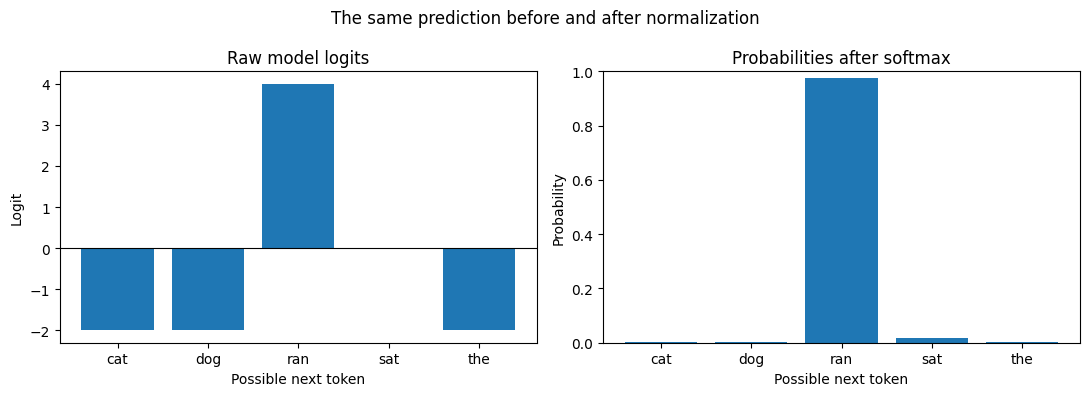

In [9]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(vocabulary, example_logits)
axes[0].set_xlabel("Possible next token")
axes[0].set_ylabel("Logit")
axes[0].set_title("Raw model logits")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[1].bar(vocabulary, example_probabilities)
axes[1].set_xlabel("Possible next token")
axes[1].set_ylabel("Probability")
axes[1].set_title("Probabilities after softmax")
axes[1].set_ylim(0, 1)
figure.suptitle("The same prediction before and after normalization")
figure.tight_layout()
plt.show()

## Measure Predictions With Loss

During training, the target tells us which probability to inspect.

For one example, **negative log loss** is `-log(probability assigned to the correct token)`.

Its behavior is useful:

- probability near 1 produces loss near 0; and
- probability near 0 produces a large loss.

A valid target probability must be greater than 0 and no greater than 1.

In [10]:
def negative_log_loss(target_probability: float) -> float:
    if not 0.0 < target_probability <= 1.0:
        raise ValueError("target_probability must be in the interval (0, 1]")
    return -math.log(target_probability)


def evaluate_toy_model(
    training_examples: list[tuple[list[int], int]],
    id_to_token: dict[int, str],
    vocabulary: list[str],
) -> float:
    if not training_examples:
        raise ValueError("training_examples must not be empty")

    losses: list[float] = []
    for example_number, (input_ids, target_id) in enumerate(training_examples, start=1):
        logits = toy_score_model(input_ids, id_to_token, vocabulary)
        probabilities = convert_logits_to_probabilities(logits)
        target_probability = probabilities[target_id]
        loss = negative_log_loss(target_probability)
        losses.append(loss)
        print(
            f"Example {example_number}: "
            f"input={decode_token_ids(input_ids, id_to_token)}, "
            f"target={id_to_token[target_id]!r}, "
            f"probability={target_probability:.4f}, loss={loss:.4f}"
        )

    return sum(losses) / len(losses)


average_loss = evaluate_toy_model(training_examples, id_to_token, vocabulary)
print("Average loss:", average_loss)

Example 1: input=['the', 'dog'], target='ran', probability=0.9749, loss=0.0254
Example 2: input=['dog', 'ran'], target='the', probability=0.9902, loss=0.0099
Example 3: input=['ran', 'the'], target='cat', probability=0.4866, loss=0.7203
Example 4: input=['the', 'cat'], target='sat', probability=0.9749, loss=0.0254
Average loss: 0.1952419985440854


The toy rules fit all four examples well, so every correct token receives high probability and the average loss is low.

A real model begins with imperfect logits and uses loss to update learnable parameters.

This toy model calculates loss but does not learn from it.

## Use the Same Model for Generation

Training and generation call the same model for different purposes:

- During **training**, the known target selects a probability used to calculate loss.
- During **generation**, no target is available, so a decoding strategy chooses from the predicted distribution.

The generator below repeatedly keeps the most recent context, computes logits and probabilities, samples one token ID, decodes it, and appends it.

A fixed seed makes the stored output reproducible.

In [11]:
import random


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    token_ids = list(range(len(probabilities)))
    return random_generator.choices(token_ids, weights=probabilities, k=1)[0]


def generate_tokens(
    starting_tokens: list[str],
    number_of_new_tokens: int,
    context_length: int,
    token_to_id: dict[str, int],
    id_to_token: dict[int, str],
    vocabulary: list[str],
    random_seed: int,
) -> list[str]:
    if context_length < 1:
        raise ValueError("context_length must be at least 1")
    if len(starting_tokens) < context_length:
        raise ValueError("starting_tokens must fill the initial context")

    random_generator = random.Random(random_seed)
    generated_tokens = starting_tokens.copy()
    for generation_step in range(number_of_new_tokens):
        generated_ids = encode_tokens(generated_tokens, token_to_id)
        input_ids = generated_ids[-context_length:]
        logits = toy_score_model(input_ids, id_to_token, vocabulary)
        probabilities = convert_logits_to_probabilities(logits)
        next_token_id = sample_token_id(probabilities, random_generator)
        next_token = id_to_token[next_token_id]
        generated_tokens.append(next_token)
        print(
            f"Step {generation_step + 1}: "
            f"input={decode_token_ids(input_ids, id_to_token)}, "
            f"sampled={next_token!r}"
        )

    return generated_tokens


generated_tokens = generate_tokens(
    starting_tokens=["the", "dog"],
    number_of_new_tokens=4,
    context_length=context_length,
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    vocabulary=vocabulary,
    random_seed=3,
)
print("Generated tokens:", generated_tokens)
print("Generated text:", " ".join(generated_tokens))

Step 1: input=['the', 'dog'], sampled='ran'
Step 2: input=['dog', 'ran'], sampled='the'
Step 3: input=['ran', 'the'], sampled='cat'
Step 4: input=['the', 'cat'], sampled='sat'
Generated tokens: ['the', 'dog', 'ran', 'the', 'cat', 'sat']
Generated text: the dog ran the cat sat


The continuation looks coherent because the rules were written specifically for this fixture.

The example demonstrates the generation loop, not learning or generalization.

## Context Length Changes the Dataset

A longer context gives the model more previous tokens, but a fixed sequence then contains fewer training windows.

With `n` tokens and context length `c`, this construction produces `n - c` examples.

For real models, longer contexts also increase memory and computation.

This plot isolates only the example-count tradeoff in our six-token fixture.

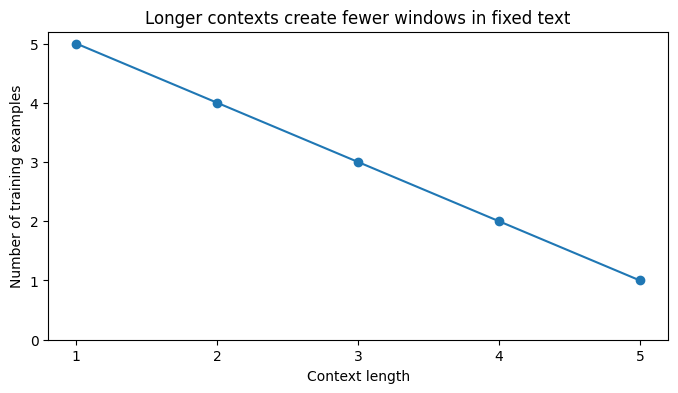

In [12]:
possible_context_lengths = list(range(1, len(token_ids)))
example_counts = [
    len(token_ids) - possible_length for possible_length in possible_context_lengths
]
plt.figure(figsize=(8, 4))
plt.plot(possible_context_lengths, example_counts, marker="o")
plt.xlabel("Context length")
plt.ylabel("Number of training examples")
plt.title("Longer contexts create fewer windows in fixed text")
plt.xticks(possible_context_lengths)
plt.ylim(bottom=0)
plt.show()

## Limits of the Word-Level Vocabulary

The vocabulary is fixed after it is built.

Our encoder cannot represent unseen words such as `bird` or `flew`, and the model cannot directly output them.

Production tokenizers solve this with strategies such as unknown tokens or subword units.

The next cell checks membership explicitly instead of allowing a less informative dictionary error.

In [13]:
new_tokens = tokenize_words("the bird flew")
print("Encoding availability:")
for token in new_tokens:
    if token in token_to_id:
        print(f"  {token!r} has ID {token_to_id[token]}")
    else:
        print(f"  {token!r} is not in the vocabulary")

Encoding availability:
  'the' has ID 4
  'bird' is not in the vocabulary
  'flew' is not in the vocabulary


## Character Tokens Preserve the Fixture

Character-level tokenization treats every character—including spaces and newlines—as a token.

It avoids unknown English words as long as their characters are in the vocabulary and can reconstruct this cleaned fixture exactly.

The tradeoff is a longer token sequence.

This is why the first trainable models in the course will use characters: the tokenizer is simple, even though the sequences are longer.

In [14]:
character_tokens = list(cleaned_text)
character_vocabulary = sorted(set(character_tokens))
character_to_id = {
    character: character_id
    for character_id, character in enumerate(character_vocabulary)
}
id_to_character = {
    character_id: character for character, character_id in character_to_id.items()
}
character_ids = [character_to_id[character] for character in character_tokens]
decoded_characters = [id_to_character[character_id] for character_id in character_ids]
decoded_character_text = "".join(decoded_characters)
print("Character tokens:", character_tokens)
print("Character vocabulary:", character_vocabulary)
print("Character IDs:", character_ids)
print("Decoded text:", repr(decoded_character_text))
print("Exact round trip succeeds:", decoded_character_text == cleaned_text)

Character tokens: ['t', 'h', 'e', ' ', 'd', 'o', 'g', ' ', 'r', 'a', 'n', '\n', 't', 'h', 'e', ' ', 'c', 'a', 't', ' ', 's', 'a', 't']
Character vocabulary: ['\n', ' ', 'a', 'c', 'd', 'e', 'g', 'h', 'n', 'o', 'r', 's', 't']
Character IDs: [12, 7, 5, 1, 4, 9, 6, 1, 10, 2, 8, 0, 12, 7, 5, 1, 3, 2, 12, 1, 11, 2, 12]
Decoded text: 'the dog ran\nthe cat sat'
Exact round trip succeeds: True


The comparison below is specific to this tiny fixture.

Its purpose is to show that tokenization changes both sequence length and vocabulary size; realistic corpora have very different scales.

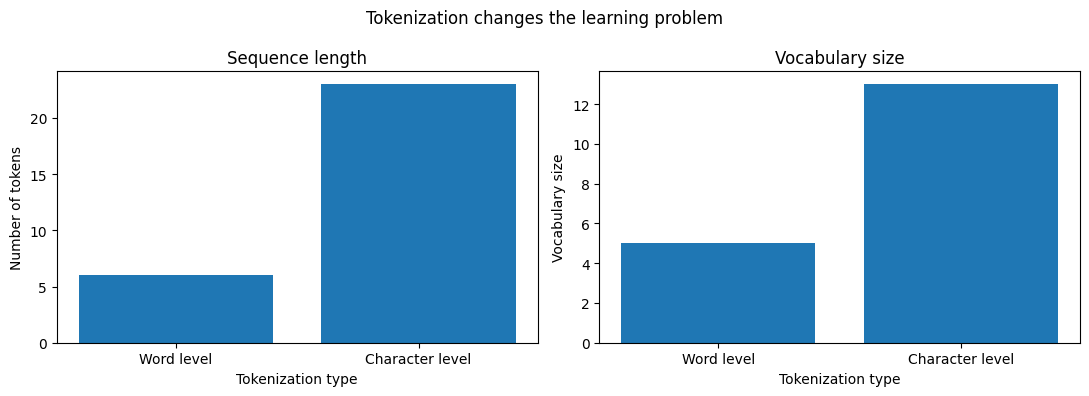

In [15]:
tokenization_types = ["Word level", "Character level"]
token_counts = [len(tokens), len(character_tokens)]
vocabulary_sizes = [len(vocabulary), len(character_vocabulary)]
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(tokenization_types, token_counts)
axes[0].set_xlabel("Tokenization type")
axes[0].set_ylabel("Number of tokens")
axes[0].set_title("Sequence length")
axes[1].bar(tokenization_types, vocabulary_sizes)
axes[1].set_xlabel("Tokenization type")
axes[1].set_ylabel("Vocabulary size")
axes[1].set_title("Vocabulary size")
figure.suptitle("Tokenization changes the learning problem")
figure.tight_layout()
plt.show()

## What Training Will Add

This chapter stops after measuring the toy model.

A trainable model adds parameters—numbers that can change—and repeatedly performs four operations:

1. Produce logits for training contexts.
2. Calculate loss from the correct targets.
3. Determine how each parameter affected that loss.
4. Update the parameters to reduce future loss.

Understanding text preparation, targets, logits, probabilities, and loss first makes those updates much easier to reason about.

## Key Takeaways

- Cleaning and tokenization determine what information reaches the model.
- A vocabulary maps each supported token to an arbitrary integer ID.
- A next-token example pairs a context with the token immediately after it.
- A model produces one logit per vocabulary token; softmax turns those logits into probabilities.
- Loss measures the probability assigned to the known target during training.
- Generation uses the same model without a known target and chooses tokens through a decoding strategy.
- Word and character tokenization create different sequence lengths, vocabularies, and information loss.

## Next Chapter

The next chapter will establish consistent habits for inspecting data, shapes, randomness, and intermediate results.

Those habits become essential as the small lists in this chapter grow into arrays, batches, and trainable models.